In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.preprocessing import QuantileTransformer

In [2]:
df = pd.read_csv("./data/titanic_clean.csv")

print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")
print(f"Valores nulos: {df.isnull().sum().sum()}")

df.head()

Filas: 891
Columnas: 8
Valores nulos: 0


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    str    
 3   Age       891 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Embarked  891 non-null    str    
dtypes: float64(2), int64(4), str(2)
memory usage: 55.8 KB


In [4]:
label_sex = LabelEncoder()
label_embarked = LabelEncoder()

df["Sex"] = label_sex.fit_transform(df["Sex"])
df["Embarked"] = label_embarked.fit_transform(df["Embarked"])

print("Codificación de Sex:")
print(dict(enumerate(label_sex.classes_)))

print("\nCodificación de Embarked:")
print(dict(enumerate(label_embarked.classes_)))

df.sample(5)

Codificación de Sex:
{0: 'female', 1: 'male'}

Codificación de Embarked:
{0: 'C', 1: 'Q', 2: 'S'}


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
398,0,2,1,23.0,0,0,10.5000,2
471,0,3,1,38.0,0,0,8.6625,2
10,1,3,0,4.0,1,1,16.7000,2
144,0,2,1,18.0,0,0,11.5000,2
162,0,3,1,26.0,0,0,7.7750,2


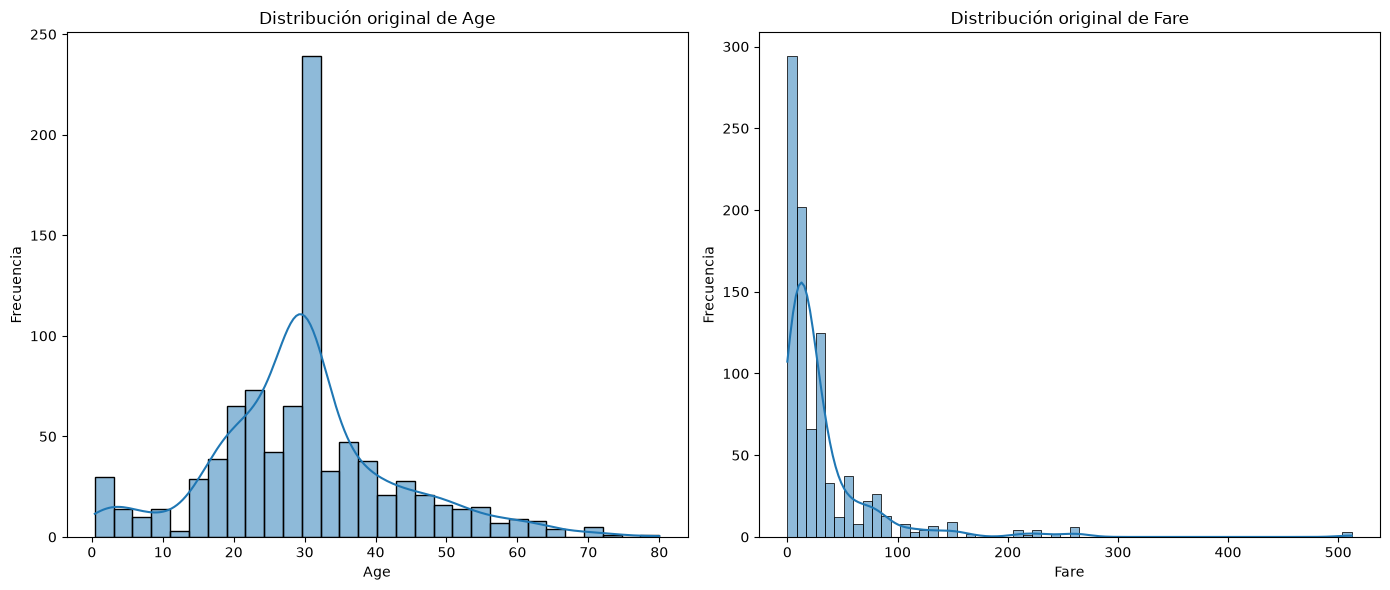

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.histplot(
    df["Age"],
    kde=True,
    ax=axes[0]
)
axes[0].set_title("Distribución original de Age")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Frecuencia")

sns.histplot(
    df["Fare"],
    kde=True,
    ax=axes[1]
)
axes[1].set_title("Distribución original de Fare")
axes[1].set_xlabel("Fare")
axes[1].set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()

In [6]:
qun_tra_age = QuantileTransformer(
    output_distribution="normal",
    n_quantiles=500,
    random_state=42
)

qun_tra_fare = QuantileTransformer(
    output_distribution="normal",
    n_quantiles=500,
    random_state=42
)

df["Age"] = qun_tra_age.fit_transform(
    df[["Age"]]
).ravel()

df["Fare"] = qun_tra_fare.fit_transform(
    df[["Fare"]]
).ravel()

df[["Age", "Fare"]].head()

,Age,Fare
0,-0.695130,-1.371110
1,0.825976,1.196857
2,-0.391550,-0.641740
3,0.663494,0.989036
4,0.663494,-0.537123


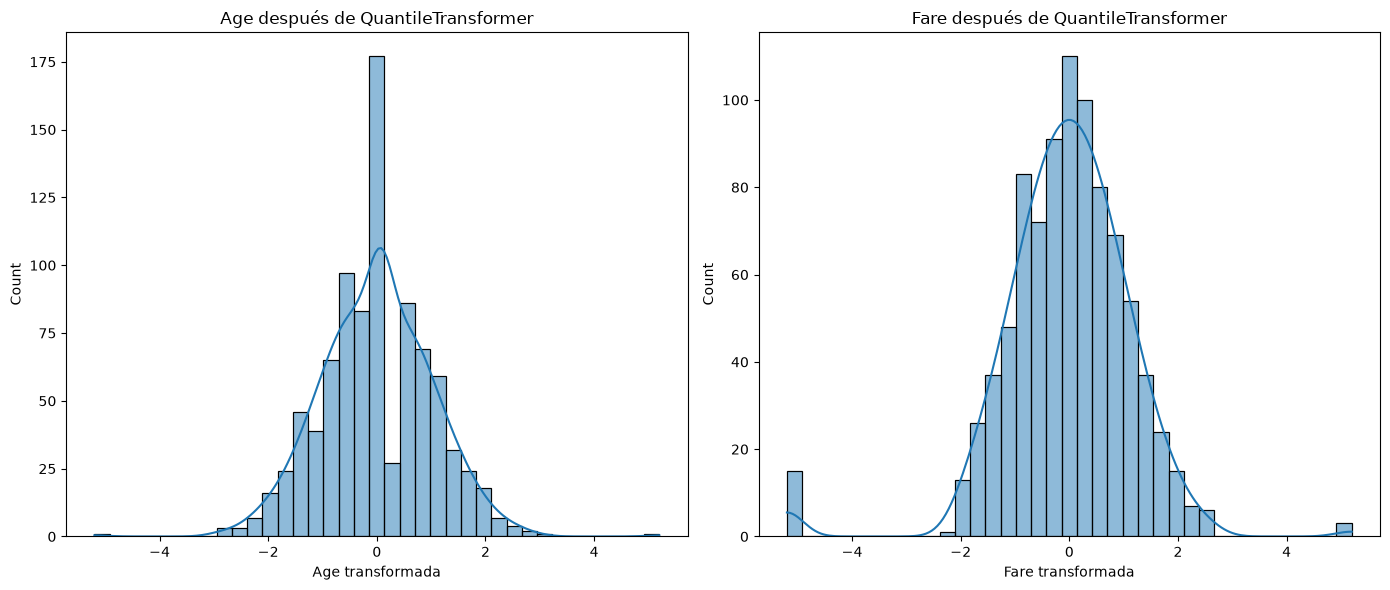

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.histplot(
    df["Age"],
    kde=True,
    ax=axes[0]
)
axes[0].set_title("Age después de QuantileTransformer")
axes[0].set_xlabel("Age transformada")

sns.histplot(
    df["Fare"],
    kde=True,
    ax=axes[1]
)
axes[1].set_title("Fare después de QuantileTransformer")
axes[1].set_xlabel("Fare transformada")

plt.tight_layout()
plt.show()

In [8]:
columnas_escaladas = [
    "Pclass",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Embarked"
]

escaladores = {}

for columna in columnas_escaladas:
    escalador = MinMaxScaler()

    df[columna] = escalador.fit_transform(
        df[[columna]]
    ).ravel()

    escaladores[columna] = escalador

In [9]:
df.sample(5)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
53,1,0.5,0.0,0.480545,0.125,0.0,0.537393,1.0
759,1,0.0,0.0,0.553335,0.000,0.0,0.640403,1.0
226,1,0.5,1.0,0.407990,0.000,0.0,0.474087,1.0
185,0,0.0,1.0,0.507253,0.000,0.0,0.588082,1.0
502,0,1.0,0.0,0.507253,0.000,0.0,0.378855,0.5


In [10]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Survived,891.0,0.383838,0.486592,0.0,0.000000,0.000000,1.000000,1.0
Pclass,891.0,0.654321,0.418036,0.0,0.500000,1.000000,1.000000,1.0
Sex,891.0,0.647587,0.477990,0.0,0.000000,1.000000,1.000000,1.0
Age,891.0,0.499922,0.098096,0.0,0.433152,0.507253,0.563806,1.0
SibSp,891.0,0.065376,0.137843,0.0,0.000000,0.000000,0.125000,1.0
Parch,891.0,0.063599,0.134343,0.0,0.000000,0.000000,0.000000,1.0
Fare,891.0,0.496364,0.114388,0.0,0.433372,0.499517,0.564712,1.0
Embarked,891.0,0.768238,0.395752,0.0,0.500000,1.000000,1.000000,1.0


In [11]:
print("Tipos de datos:")
print(df.dtypes)

print("\nValores nulos:")
print(df.isnull().sum())

print(f"\nDimensiones finales: {df.shape}")

Tipos de datos:
Survived      int64
Pclass      float64
Sex         float64
Age         float64
SibSp       float64
Parch       float64
Fare        float64
Embarked    float64
dtype: object

Valores nulos:
Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

Dimensiones finales: (891, 8)


In [12]:
df.to_csv(
    "./data/titanic_procesado.csv",
    index=False
)

print("Archivo data/titanic_procesado.csv guardado correctamente.")

Archivo data/titanic_procesado.csv guardado correctamente.
